# Notebook 2: Data Exploration & Visualization
## LAFIAKALO Holistic Health ML — De-identified Patient

**Purpose**: Explore processed health data across all domains. Understand distributions, trends, correlations, and data quality before feature engineering.

**Prerequisites**: Run `01_data_ingestion.ipynb` first — produces 12 CSVs in `data/processed/`.

### Processed Datasets
| File | Rows | Date Range | Key Columns |
|------|------|------------|-------------|
| `unified_labs.csv` | ~9,660 | 2016→2026 | test_name, value_numeric, unit, source |
| `dialysis_sessions.csv` | ~1,797 | 2016→2026 | session_date, post_weight_kg, BP, fluid, duration |
| `dialysis_readings.csv` | ~15,711 | 2017→2026 | intra-dialytic BP, UF, blood flow |
| `unified_nutrition.csv` | ~4,088 | 2016→2026 | food_item, calories, protein, sodium, potassium |
| `unified_elimination.csv` | ~2,551 | 2022→2026 | bowel tracking |
| `vomit_log.csv` | ~1,289 | 2017→2026 | intradialytic vomit events |
| `medications.csv` | ~944 | 2025→2026 | medication_name, dosage, BP pre/post |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

# Paths
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

# Load all processed datasets
labs = pd.read_csv(PROCESSED_DIR / 'unified_labs.csv', parse_dates=['date'])
sessions = pd.read_csv(PROCESSED_DIR / 'dialysis_sessions.csv', parse_dates=['session_date'])
readings = pd.read_csv(PROCESSED_DIR / 'dialysis_readings.csv')
nutrition = pd.read_csv(PROCESSED_DIR / 'unified_nutrition.csv', parse_dates=['date'])
elimination = pd.read_csv(PROCESSED_DIR / 'unified_elimination.csv', parse_dates=['date'])
# Vomit is now merged INTO unified_elimination (type='vomit')
vomit = elimination[elimination['type'] == 'vomit'].copy()
bowel = elimination[elimination['type'] == 'bowel'].copy()
meds = pd.read_csv(PROCESSED_DIR / 'medications.csv', parse_dates=['date'])
vitals = pd.read_csv(PROCESSED_DIR / 'vitals.csv')

print("Loaded processed data:")
for name, df in [('Labs', labs), ('Sessions', sessions), ('Readings', readings),
                  ('Nutrition', nutrition), ('Elimination', elimination),
                  ('  Bowel', bowel), ('  Vomit', vomit),
                  ('Medications', meds), ('Vitals', vitals)]:
    print(f"  {name:15s} {len(df):>7,} rows × {df.shape[1]} cols")

Loaded processed data:
  Labs              9,660 rows × 18 cols
  Sessions          1,797 rows × 105 cols
  Readings         15,711 rows × 14 cols
  Nutrition         4,094 rows × 33 cols
  Elimination       3,844 rows × 17 cols
    Bowel           2,469 rows × 17 cols
    Vomit           1,375 rows × 17 cols
  Medications         953 rows × 13 cols
  Vitals               15 rows × 11 cols


---
## 1. Data Coverage Timeline
When do we have data for each domain?

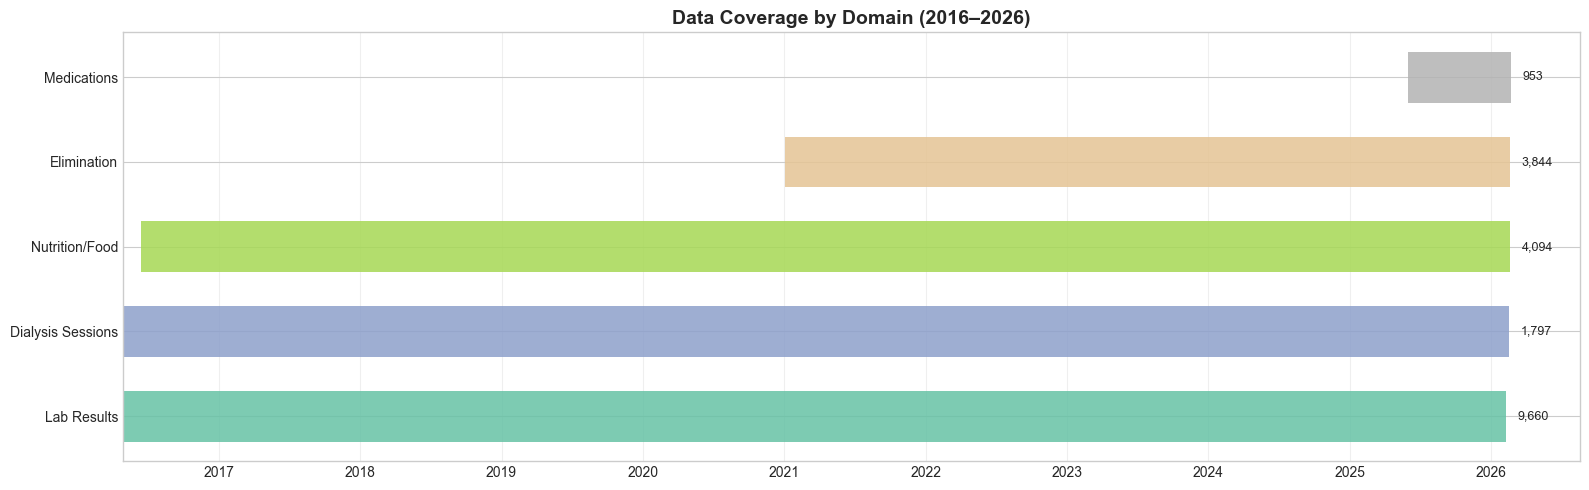

In [2]:
# ── Data coverage timeline (already done in NB01, streamlined here) ──
fig, ax = plt.subplots(figsize=(16, 5))

domains = [
    ('Lab Results', labs['date']),
    ('Dialysis Sessions', sessions['session_date']),
    ('Nutrition/Food', nutrition['date']),
    ('Elimination', elimination['date']),
    ('Medications', meds['date']),
]
colors = plt.cm.Set2(np.linspace(0, 1, len(domains)))

for i, (name, dates) in enumerate(domains):
    d = dates.dropna()
    if not d.empty:
        ax.barh(i, (d.max() - d.min()).days, left=mdates.date2num(d.min()),
                height=0.6, color=colors[i], alpha=0.85)
        ax.text(mdates.date2num(d.max()) + 30, i, f"{len(d):,}", va='center', fontsize=9)

ax.set_yticks(range(len(domains)))
ax.set_yticklabels([d[0] for d in domains])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_title('Data Coverage by Domain (2016–2026)', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Dialysis Sessions Analysis
1,797 sessions spanning 2016–2026. Key metrics: weight, BP, fluid removed, vomit events.

In [3]:
# Session overview
print(f"Dialysis sessions: {len(sessions):,}")
print(f"Date range: {sessions['session_date'].min().date()} → {sessions['session_date'].max().date()}")
print(f"\nNumeric columns ({sessions.select_dtypes(include=[np.number]).shape[1]}):")

key_cols = [c for c in sessions.columns if any(k in c.lower() for k in 
            ['weight', 'bp', 'sys', 'dia', 'pulse', 'fluid', 'duration', 'blood_flow', 'uf'])]
print(f"Key session columns: {key_cols}")
display(sessions[key_cols].describe().round(2))

Dialysis sessions: 1,797
Date range: 2016-04-28 → 2026-02-17

Numeric columns (76):
Key session columns: ['today_weight_kg', 'post_weight_kg', 'weight_loss_kg', 'pre_bp_sys', 'pre_bp_dia', 'post_bp_sys', 'post_bp_dia', 'bp_lowest_sys', 'bp_lowest_dia', 'pre_pulse', 'post_pulse', 'avg_blood_flow_rate', 'avg_dialysate_rate', 'weight_gain_bt', 'pre_stand_bp_sys', 'pre_stand_bp_dia', 'previous_post_weight', 'today_weight', 'dry_weight', 'fluid_to_remove', 'weight_unit', 'previous_post_weight_kg', 'dry_weight_kg', 'fluid_to_remove_kg', 'dialysate_volume_L', 'dialysate_lactate', 'dialysate_k', 'prescribed_blood_flow_rate', 'avg_bp_sys', 'avg_bp_dia', 'avg_pulse', 'post_stand_bp_sys', 'post_stand_bp_dia', 'post_weight', 'total_dialysate_L', 'total_uf_kg', 'post_stand_pulse', 'pre_weight_kg', 'target_weight_kg', 'fluid_removed_liters', 'pre_bp_sitting_sys', 'pre_bp_sitting_dia', 'pre_bp_standing_sys', 'pre_bp_standing_dia', 'post_bp_sitting_sys', 'post_bp_sitting_dia', 'post_bp_standing_sys', 

,today_weight_kg,post_weight_kg,weight_loss_kg,pre_bp_sys,pre_bp_dia,post_bp_sys,post_bp_dia,bp_lowest_sys,bp_lowest_dia,pre_pulse,...,pre_bp_sitting_dia,pre_bp_standing_sys,pre_bp_standing_dia,post_bp_sitting_sys,post_bp_sitting_dia,post_bp_standing_sys,post_bp_standing_dia,total_dialysate_liters,dialyzer_lot,dialysate_lot
count,1714.00,1638.00,1626.00,1566.00,1563.00,1501.00,1501.00,29.00,29.00,1532.00,...,5.00,0.0,0.0,5.00,5.00,0.0,0.0,5.00,5.0,5.0
mean,60.84,60.26,0.58,124.26,80.55,107.91,67.89,135.79,78.28,101.20,...,74.80,NaN,NaN,97.40,72.00,NaN,NaN,54.02,50377123.0,50281030.0
std,4.97,14.51,14.23,28.16,16.52,31.55,18.23,23.04,16.12,11.14,...,12.64,NaN,NaN,7.67,5.74,NaN,NaN,15.40,0.0,0.0
min,45.80,45.40,-551.80,61.00,39.00,51.00,31.00,90.00,32.00,5.00,...,63.00,NaN,NaN,88.00,65.00,NaN,NaN,26.80,50377123.0,50281030.0
25%,58.70,58.40,0.10,100.00,67.00,82.00,53.00,120.00,71.00,95.00,...,66.00,NaN,NaN,94.00,71.00,NaN,NaN,56.80,50377123.0,50281030.0
50%,61.00,60.25,0.70,120.00,79.00,100.00,63.00,140.00,81.00,101.00,...,68.00,NaN,NaN,98.00,71.00,NaN,NaN,61.50,50377123.0,50281030.0
75%,64.20,62.80,1.40,147.00,94.00,133.00,81.00,157.00,91.00,108.00,...,88.00,NaN,NaN,98.00,72.00,NaN,NaN,62.10,50377123.0,50281030.0
max,72.00,614.00,69.50,202.00,134.00,208.00,158.00,168.00,100.00,140.00,...,89.00,NaN,NaN,109.00,81.00,NaN,NaN,62.90,50377123.0,50281030.0


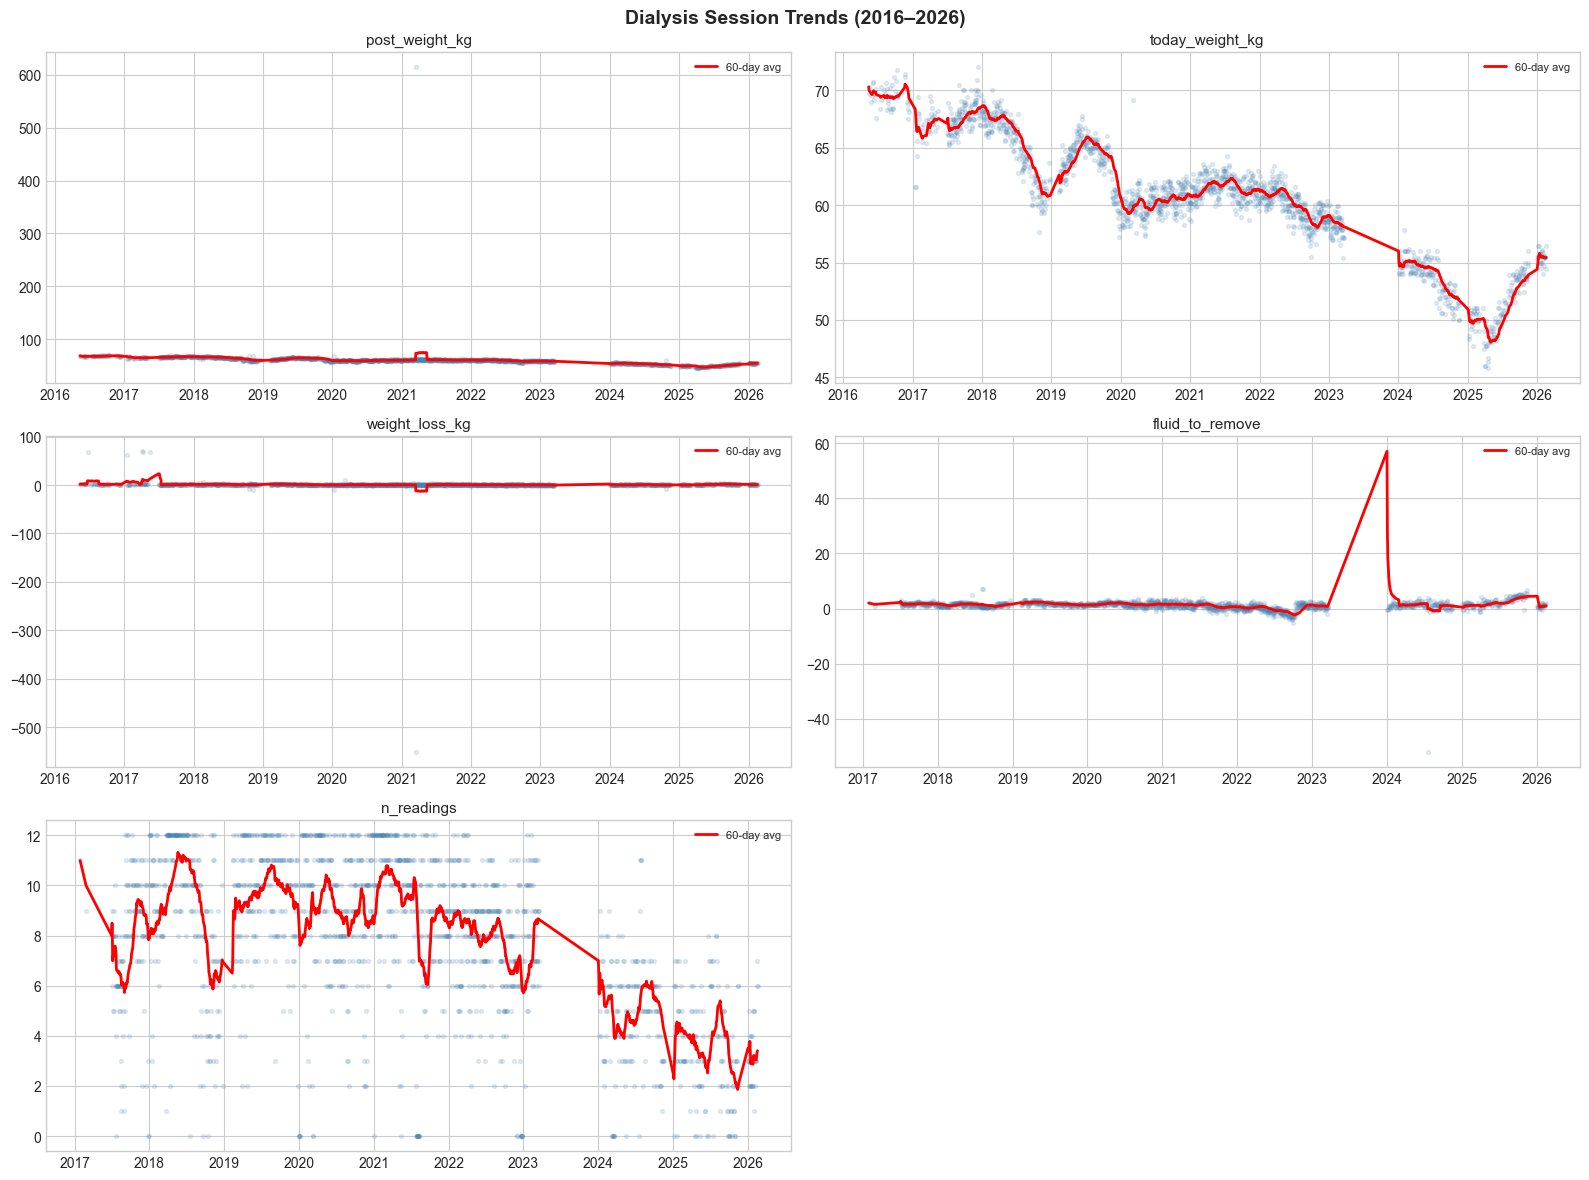

In [4]:
# ── Dialysis trends over time ──
# Plot weight and key metrics with rolling averages
s = sessions.sort_values('session_date').set_index('session_date')

# Pick up to 6 key numeric columns that exist
trend_cols = []
for c in ['post_weight_kg', 'today_weight_kg', 'weight_loss_kg', 
          'fluid_removed_L', 'fluid_to_remove', 'n_readings',
          'pre_sys', 'pre_dia', 'post_sys', 'post_dia',
          'blood_flow', 'duration_hrs']:
    if c in s.columns and s[c].notna().sum() > 50:
        trend_cols.append(c)
    if len(trend_cols) == 6:
        break

n = len(trend_cols)
if n > 0:
    fig, axes = plt.subplots((n+1)//2, 2, figsize=(16, 4*((n+1)//2)))
    axes = axes.flatten()
    
    for i, col in enumerate(trend_cols):
        ax = axes[i]
        data = s[col].dropna()
        ax.scatter(data.index, data.values, alpha=0.15, s=8, color='steelblue')
        rolling = data.rolling('60D').mean()
        ax.plot(rolling.index, rolling.values, color='red', linewidth=2, label='60-day avg')
        ax.set_title(col, fontsize=11)
        ax.legend(fontsize=8)
    
    # Hide unused axes
    for j in range(n, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Dialysis Session Trends (2016–2026)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 3. Lab Results Analysis
9,660 results across 341 tests. Focus on key renal markers with longitudinal trends.

In [5]:
# Lab test frequency
test_freq = labs.groupby('test_name').agg(
    n=('value_numeric', 'count'),
    n_numeric=('value_numeric', lambda x: x.notna().sum()),
    first=('date', 'min'),
    last=('date', 'max'),
).sort_values('n', ascending=False)

print(f"Unique lab tests: {len(test_freq)}")
print(f"Tests with ≥10 numeric results: {(test_freq['n_numeric'] >= 10).sum()}")
print(f"Tests with ≥50 numeric results: {(test_freq['n_numeric'] >= 50).sum()}")

print("\nTop 30 most frequent tests:")
display(test_freq.head(30))

Unique lab tests: 341
Tests with ≥10 numeric results: 89
Tests with ≥50 numeric results: 62

Top 30 most frequent tests:


,n,n_numeric,first,last
test_name,,,,
Hemoglobin,220,220,2016-05-14,2025-08-18
Potassium,214,214,2016-05-14,2025-08-18
BUN,206,206,2016-05-14,2026-02-09
Creatnine,199,199,2016-05-14,2024-08-29
Chloride,192,192,2016-05-14,2025-08-18
HCT CALC (HBGX3),192,192,2016-04-28,2024-08-29
Hematocrit,187,187,2016-05-14,2025-08-18
CO2 (Bicarbonate),186,186,2016-05-14,2024-08-29
RBC,182,182,2016-05-14,2026-02-09


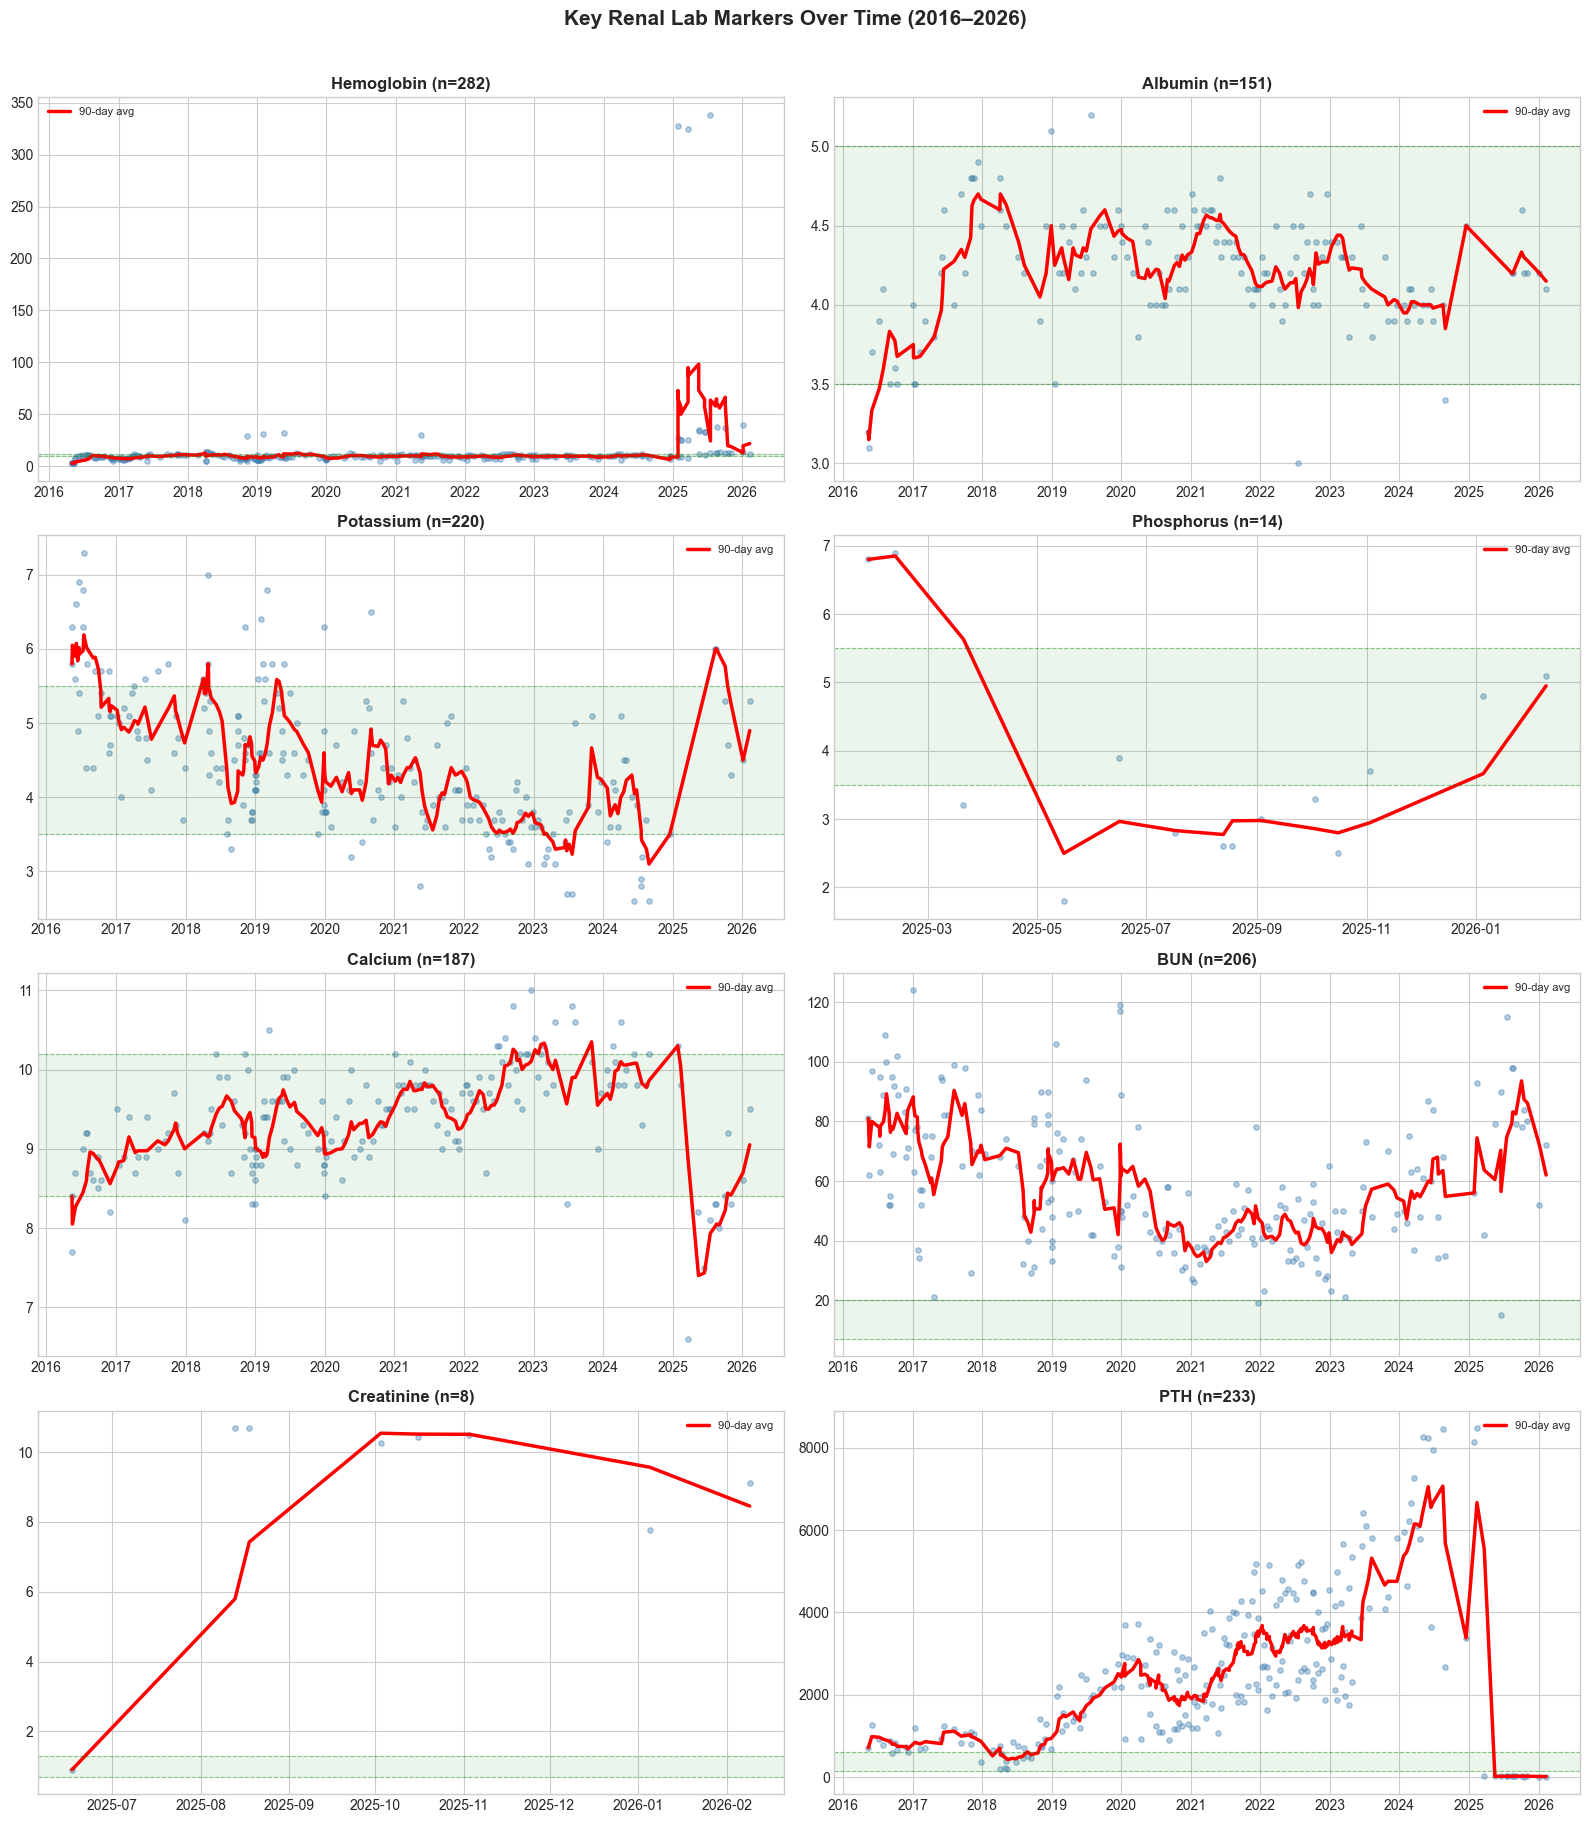

In [6]:
# ── Key renal lab trends ──
# Match test names (partial, case-insensitive)
KEY_LABS = {
    'Hemoglobin': 'Hemoglobin|HGB',
    'Albumin': '^Albumin$',
    'Potassium': '^Potassium$|^K$',
    'Phosphorus': '^Phosphorus$|^Phos$',
    'Calcium': '^Calcium$|^Ca$',
    'BUN': '^BUN$|Urea Nitrogen',
    'Creatinine': '^Creatinine$',
    'PTH': 'PTH|Parathyroid',
}

# Reference ranges for ESRD patient (approximate)
REF_RANGES = {
    'Hemoglobin': (10, 12),       # g/dL — ESRD target
    'Albumin': (3.5, 5.0),        # g/dL
    'Potassium': (3.5, 5.5),      # mEq/L
    'Phosphorus': (3.5, 5.5),     # mg/dL
    'Calcium': (8.4, 10.2),       # mg/dL
    'BUN': (7, 20),               # mg/dL
    'Creatinine': (0.7, 1.3),     # mg/dL (elevated expected in ESRD)
    'PTH': (150, 600),            # pg/mL — ESRD target
}

fig, axes = plt.subplots(4, 2, figsize=(16, 18))

for ax, (label, pattern) in zip(axes.flatten(), KEY_LABS.items()):
    mask = labs['test_name'].str.contains(pattern, case=False, na=False, regex=True)
    subset = labs[mask].dropna(subset=['date', 'value_numeric']).sort_values('date')
    
    if len(subset) > 0:
        ax.scatter(subset['date'], subset['value_numeric'], alpha=0.4, s=15, color='steelblue')
        
        if len(subset) > 5:
            rolling = subset.set_index('date')['value_numeric'].rolling('90D').mean()
            ax.plot(rolling.index, rolling.values, 'r-', linewidth=2.5, label='90-day avg')
        
        # Reference range
        if label in REF_RANGES:
            lo, hi = REF_RANGES[label]
            ax.axhspan(lo, hi, alpha=0.08, color='green')
            ax.axhline(y=lo, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
            ax.axhline(y=hi, color='green', linestyle='--', alpha=0.4, linewidth=0.8)
        
        ax.set_title(f"{label} (n={len(subset)})", fontsize=12, fontweight='bold')
        ax.legend(fontsize=8)
    else:
        ax.text(0.5, 0.5, f'{label}\nNo matches', ha='center', va='center',
                transform=ax.transAxes, fontsize=12, color='gray')

plt.suptitle('Key Renal Lab Markers Over Time (2016–2026)', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Nutrition & Food Log Analysis
4,088 entries spanning 2016–2026 (Records.xlsx + Firestore).

In [7]:
print(f"Nutrition entries: {len(nutrition):,}")
print(f"Date range: {nutrition['date'].min().date()} → {nutrition['date'].max().date()}")
print(f"Sources: {nutrition['source'].value_counts().to_dict()}")
print(f"\nAll columns: {list(nutrition.columns)}")

# Numeric nutrition columns
numeric_nutr = nutrition.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns: {numeric_nutr}")
if numeric_nutr:
    display(nutrition[numeric_nutr].describe().round(2))

Nutrition entries: 4,094
Date range: 2016-06-14 → 2026-02-19
Sources: {'records_xlsx': 3491, 'firestore': 603}

All columns: ['date', 'time_slot', 'description', 'source', 'start_time', 'end_time', 'quantity', 'pre_weight_kg', 'post_weight_kg', 'state_post', 'medication', 'new_recipe', 'recipe_code', 'meal_type', 'food_item', 'pre_meal_weight_kg', 'post_meal_weight_kg', 'calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar', 'sodium', 'potassium', 'calcium', 'iron', 'phosphorus', 'vitamin_d', 'vitamin_b12', 'folic_acid', 'cholesterol', 'ai_summary']

Numeric columns: ['pre_weight_kg', 'post_weight_kg', 'pre_meal_weight_kg', 'post_meal_weight_kg', 'calories', 'protein', 'carbs', 'fat', 'fiber', 'sugar', 'sodium', 'potassium', 'calcium', 'iron', 'phosphorus', 'vitamin_d', 'vitamin_b12', 'folic_acid', 'cholesterol']


,pre_weight_kg,post_weight_kg,pre_meal_weight_kg,post_meal_weight_kg,calories,protein,carbs,fat,fiber,sugar,sodium,potassium,calcium,iron,phosphorus,vitamin_d,vitamin_b12,folic_acid,cholesterol
count,3339.00,3294.00,509.00,505.00,481.00,481.00,481.00,481.00,456.00,456.00,456.00,456.00,456.00,456.00,456.00,456.00,456.00,456.00,456.00
mean,56.10,56.63,51.98,52.38,260.02,12.71,29.09,11.74,2.30,8.17,194.96,348.02,65.28,2.14,146.32,0.95,1.18,32.45,66.62
std,4.06,4.13,2.08,2.05,367.41,20.50,40.67,19.81,3.67,13.03,377.60,468.73,117.81,3.89,213.67,4.97,4.19,55.78,123.32
min,40.50,45.40,45.50,45.70,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,53.50,54.10,50.20,50.60,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
50%,56.60,57.10,52.00,52.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
75%,59.60,60.20,53.70,54.00,483.00,24.00,51.00,18.00,3.70,13.00,215.50,603.25,80.75,3.70,274.25,0.00,1.00,42.00,88.25
max,63.20,64.00,63.20,57.00,2212.00,208.20,262.50,113.90,39.00,76.80,2370.00,2700.00,716.00,50.00,1360.00,50.00,50.40,436.00,705.00


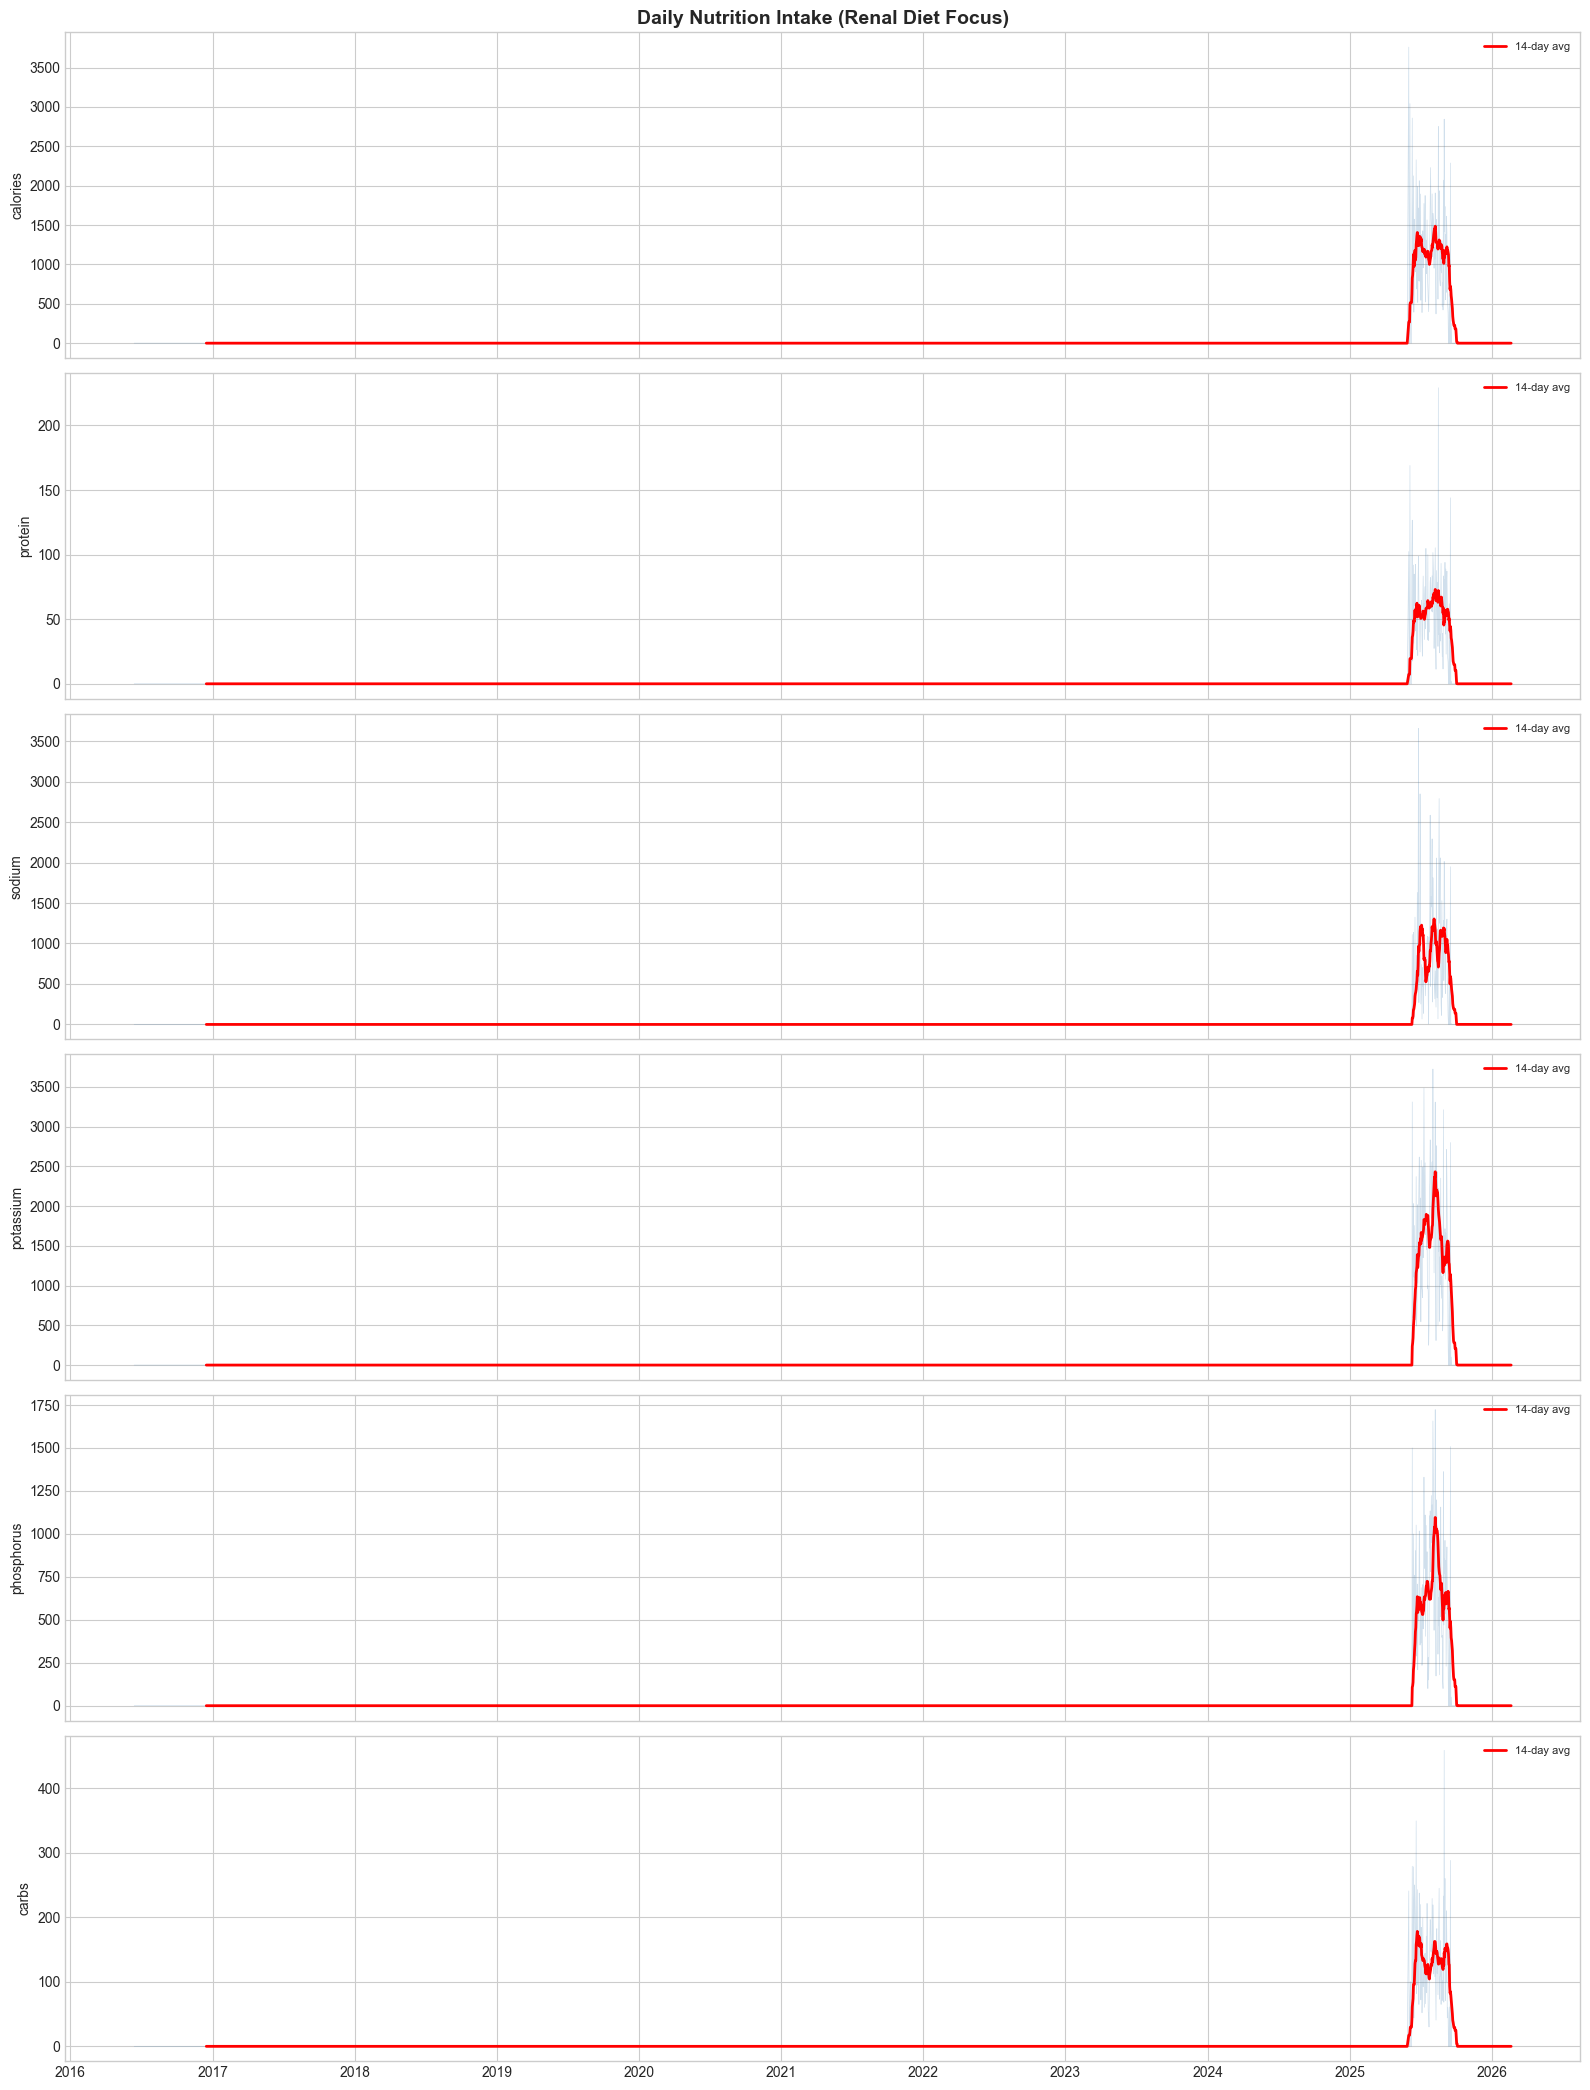

In [8]:
# ── Daily nutrition trends ──
numeric_nutr = nutrition.select_dtypes(include=[np.number]).columns.tolist()
# Prioritize key renal diet nutrients
priority = ['calories', 'protein', 'sodium', 'potassium', 'phosphorus',
            'carbs', 'fat', 'fiber', 'sugar', 'calcium', 'iron']
plot_cols = [c for c in priority if c in numeric_nutr]
if not plot_cols:
    plot_cols = numeric_nutr[:6]

if plot_cols and 'date' in nutrition.columns:
    daily_nutr = nutrition.groupby(nutrition['date'].dt.date)[plot_cols].sum()
    daily_nutr.index = pd.to_datetime(daily_nutr.index)
    
    n = min(len(plot_cols), 6)
    fig, axes = plt.subplots(n, 1, figsize=(16, 3.5 * n), sharex=True)
    if not isinstance(axes, np.ndarray):
        axes = [axes]
    
    for ax, col in zip(axes, plot_cols[:n]):
        data = daily_nutr[col].dropna()
        ax.plot(data.index, data.values, alpha=0.25, linewidth=0.5, color='steelblue')
        rolling = data.rolling(14).mean()
        ax.plot(rolling.index, rolling.values, color='red', linewidth=2, label='14-day avg')
        ax.set_ylabel(col, fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
    
    axes[0].set_title('Daily Nutrition Intake (Renal Diet Focus)', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric nutrition columns to plot.")

---
## 5. Elimination & Vomit Tracking

Total elimination entries: 3,844
  Bowel: 2,469
  Vomit: 1,375
  Sources: {'records_xlsx': 2113, 'flowsheet': 1289, 'firestore': 442}


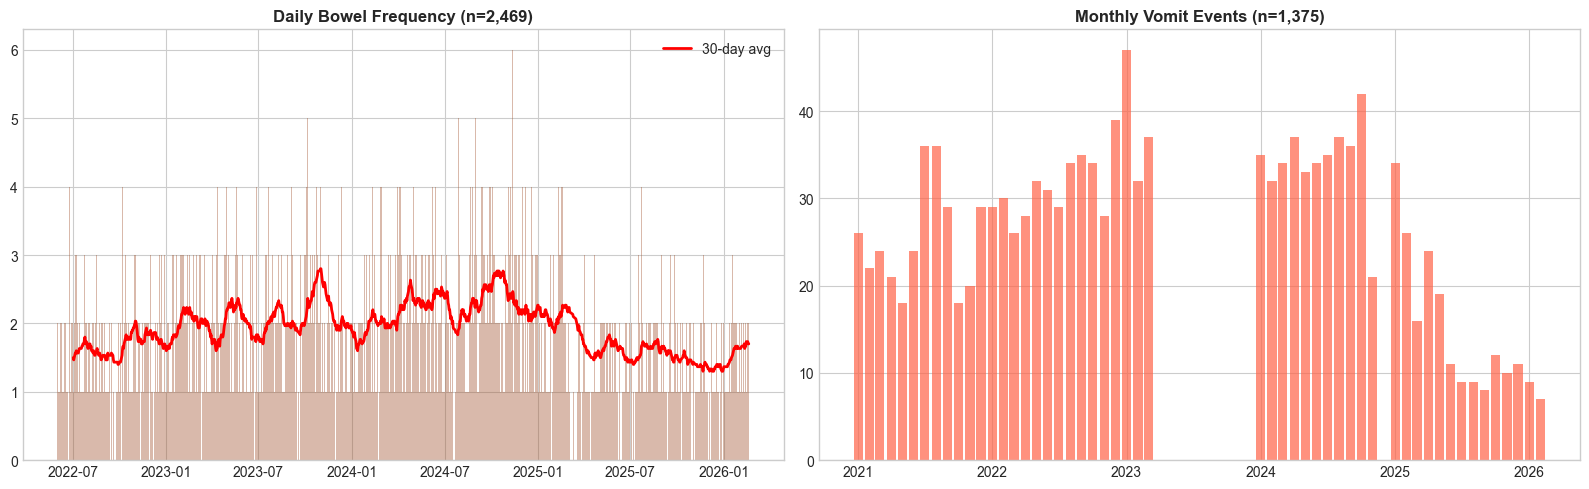

In [9]:
# ── Elimination: Bowel + Vomit (merged in unified_elimination) ──
print(f"Total elimination entries: {len(elimination):,}")
print(f"  Bowel: {len(bowel):,}")
print(f"  Vomit: {len(vomit):,}")
print(f"  Sources: {elimination['source'].value_counts().to_dict()}")

daily_bowel = bowel.groupby(bowel['date'].dt.date).size()
daily_bowel.index = pd.to_datetime(daily_bowel.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bowel frequency over time
ax = axes[0]
ax.bar(daily_bowel.index, daily_bowel.values, alpha=0.4, width=1, color='sienna')
rolling = daily_bowel.rolling(30).mean()
ax.plot(rolling.index, rolling.values, 'r-', linewidth=2, label='30-day avg')
ax.set_title(f'Daily Bowel Frequency (n={len(bowel):,})', fontsize=12, fontweight='bold')
ax.legend()

# Vomit events
ax = axes[1]
monthly_vomit = vomit.groupby(vomit['date'].dt.to_period('M')).size()
monthly_vomit.index = monthly_vomit.index.to_timestamp()
ax.bar(monthly_vomit.index, monthly_vomit.values, width=25, alpha=0.7, color='tomato')
ax.set_title(f'Monthly Vomit Events (n={len(vomit):,})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

---
## 6. Medications Analysis

In [10]:
print(f"Medication records: {len(meds):,}")
print(f"Columns: {list(meds.columns)}")

if 'medication_name' in meds.columns:
    med_counts = meds['medication_name'].value_counts()
    print(f"\nUnique medications: {len(med_counts)}")
    print("\nMedication frequency:")
    display(med_counts.head(20))

display(meds.head(10))

Medication records: 953
Columns: ['date', 'time', 'medication_name', 'dosage', 'source_provider', 'pre_bp_systolic', 'pre_bp_diastolic', 'pre_heart_rate', 'post_bp_systolic', 'post_bp_diastolic', 'post_heart_rate', 'notes', 'source']

Unique medications: 11

Medication frequency:


medication_name
Calcium Carbonate                               473
Calcitriol                                      381
Cetirizine Hydrochloride                         28
Sodium Carbonate                                 26
Folic Acid                                       13
Tramadol                                         12
Cyclobenzeprine                                   5
Oedesetron                                        2
Marine Bone Discovery                             2
Rugby Stimulant Laxative Plus Stool Softener      1
Docusolate                                        1
Name: count, dtype: int64

,date,time,medication_name,dosage,source_provider,pre_bp_systolic,pre_bp_diastolic,pre_heart_rate,post_bp_systolic,post_bp_diastolic,post_heart_rate,notes,source
0,2025-08-05,00:20,Calcium Carbonate,2000 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
1,2025-06-17,12:08,Calcium Carbonate,1500 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
2,2025-06-11,20:17,Sodium Carbonate,1500 mg,NaN,87.0,62.0,94.0,NaN,NaN,NaN,during dialysis,firestore
3,2025-06-13,21:25,Calcitriol,1 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
4,2025-08-28,01:40,Calcium Carbonate,2000 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
5,2025-07-03,10:20,Calcitriol,1 mcg/mL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
6,2025-09-10,01:49,Calcium Carbonate,2000 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
7,2025-11-27,04:25,Calcitriol,1 mcg/mL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
8,2025-12-26,05:46,Calcium Carbonate,1000 mg,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore
9,2025-07-13,12:50 AM,Calcitriol,1 mcg/mL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,firestore


---
## 7. Weight Trajectory & Body Composition
Critical ESRD metric — fluid management depends on accurate dry-weight tracking.

Weight columns: ['today_weight_kg', 'post_weight_kg', 'weight_loss_kg', 'weight_gain_bt', 'previous_post_weight', 'today_weight', 'dry_weight', 'weight_unit', 'previous_post_weight_kg', 'dry_weight_kg', 'post_weight']


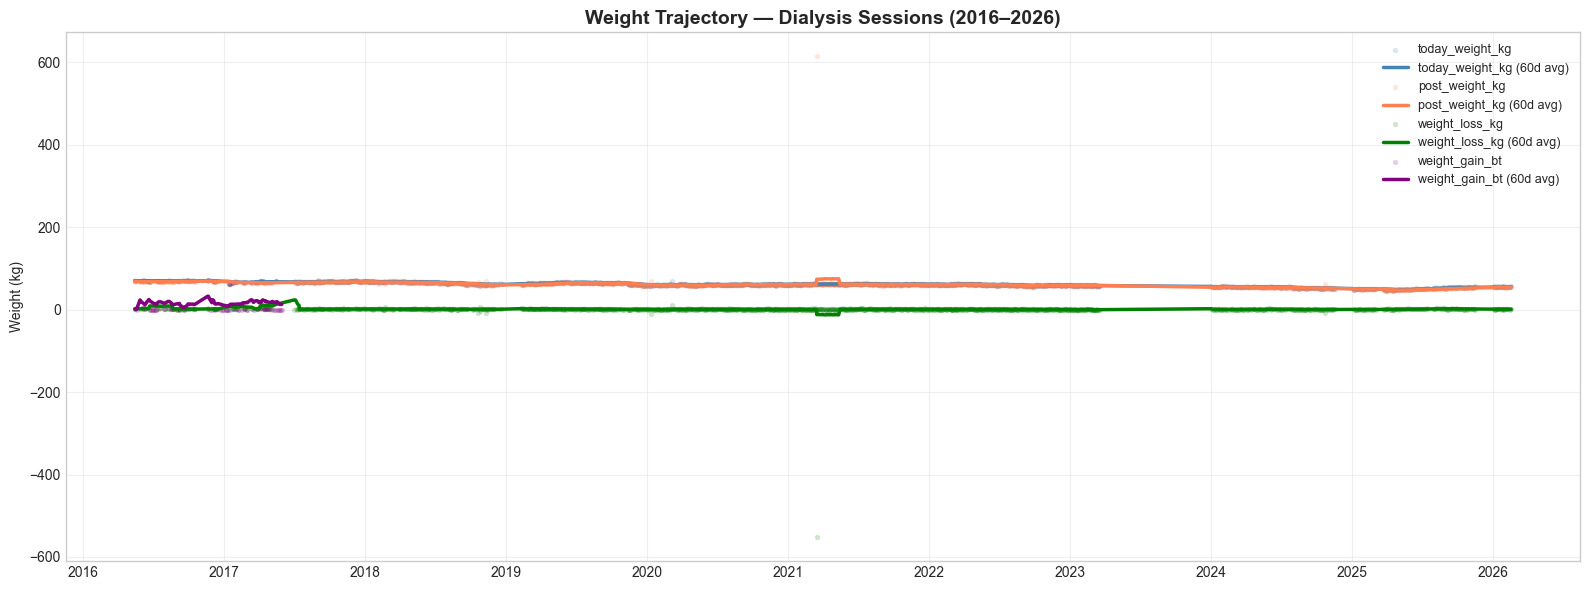


today_weight_kg by year:


,mean,std,min,max,count
year,,,,,
2016,69.5,1.0,67.5,71.8,44
2017,67.6,1.4,61.6,72.0,146
2018,65.2,2.7,57.7,70.0,210
2019,63.9,2.0,57.2,67.8,189
2020,60.3,1.2,57.3,69.2,249
2021,61.5,1.0,58.6,64.3,252
2022,59.9,1.4,55.5,63.4,262
2023,58.1,0.9,55.4,60.0,55
2024,53.7,1.6,50.0,57.8,150


In [11]:
# ── Weight trend from dialysis sessions ──
s = sessions.dropna(subset=['session_date']).sort_values('session_date').copy()

weight_cols = [c for c in s.columns if 'weight' in c.lower() and s[c].notna().sum() > 50]
print(f"Weight columns: {weight_cols}")

if weight_cols:
    fig, ax = plt.subplots(figsize=(16, 6))
    colors = ['steelblue', 'coral', 'green', 'purple']
    for col, color in zip(weight_cols[:4], colors):
        data = s[['session_date', col]].dropna()
        ax.scatter(data['session_date'], data[col], alpha=0.15, s=8, color=color, label=col)
        rolling = data.set_index('session_date')[col].rolling('60D').mean()
        ax.plot(rolling.index, rolling.values, color=color, linewidth=2.5, label=f'{col} (60d avg)')
    
    ax.set_ylabel('Weight (kg)')
    ax.set_title('Weight Trajectory — Dialysis Sessions (2016–2026)', fontsize=14, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # Weight stats by year
    s['year'] = s['session_date'].dt.year
    wt_col = weight_cols[0]
    yearly_wt = s.groupby('year')[wt_col].agg(['mean', 'std', 'min', 'max', 'count']).round(1)
    print(f"\n{wt_col} by year:")
    display(yearly_wt)

---
## 8. Cross-Domain Correlation Analysis
Build a daily summary joining labs, sessions, nutrition, elimination — measure pairwise correlations.

In [12]:
# ── Build daily unified feature matrix ──
# 1. Session features (one row per day, from dialysis sessions)
sess_daily = sessions.set_index('session_date').select_dtypes(include=[np.number])
sess_daily = sess_daily.add_prefix('sess_')

# 2. Lab pivot: wide format — one column per lab test, value = value_numeric
# For each date, pick latest result per test
lab_wide = labs.dropna(subset=['date', 'test_name', 'value_numeric']).copy()
lab_wide = lab_wide.drop_duplicates(subset=['date', 'test_name'], keep='last')
lab_wide = lab_wide.pivot_table(index='date', columns='test_name', values='value_numeric', aggfunc='last')
lab_wide = lab_wide.add_prefix('lab_')
# Forward-fill labs (they don't change daily)
lab_wide = lab_wide.resample('D').last().ffill(limit=60)

# 3. Nutrition daily totals
nutr_daily = nutrition.groupby(nutrition['date'].dt.date).agg(
    **{c: (c, 'sum') for c in nutrition.select_dtypes(include=[np.number]).columns}
)
nutr_daily.index = pd.to_datetime(nutr_daily.index)
nutr_daily = nutr_daily.add_prefix('nutr_')

# 4. Bowel daily count
bowel_daily = elimination.groupby(elimination['date'].dt.date).size().to_frame('elim_bowel_count')
bowel_daily.index = pd.to_datetime(bowel_daily.index)

# Join everything on date
daily = sess_daily.join(lab_wide, how='outer')
daily = daily.join(nutr_daily, how='outer')
daily = daily.join(bowel_daily, how='outer')
daily.index.name = 'date'

print(f"Daily unified matrix: {daily.shape[0]:,} days × {daily.shape[1]} features")
print(f"Date range: {daily.index.min().date()} → {daily.index.max().date()}")

# Coverage stats
coverage = daily.notna().mean().sort_values(ascending=False)
print(f"\nFeatures with >10% coverage: {(coverage > 0.1).sum()}")
print(f"Features with >50% coverage: {(coverage > 0.5).sum()}")

Daily unified matrix: 3,585 days × 388 features
Date range: 2016-04-28 → 2026-02-19

Features with >10% coverage: 146
Features with >50% coverage: 74


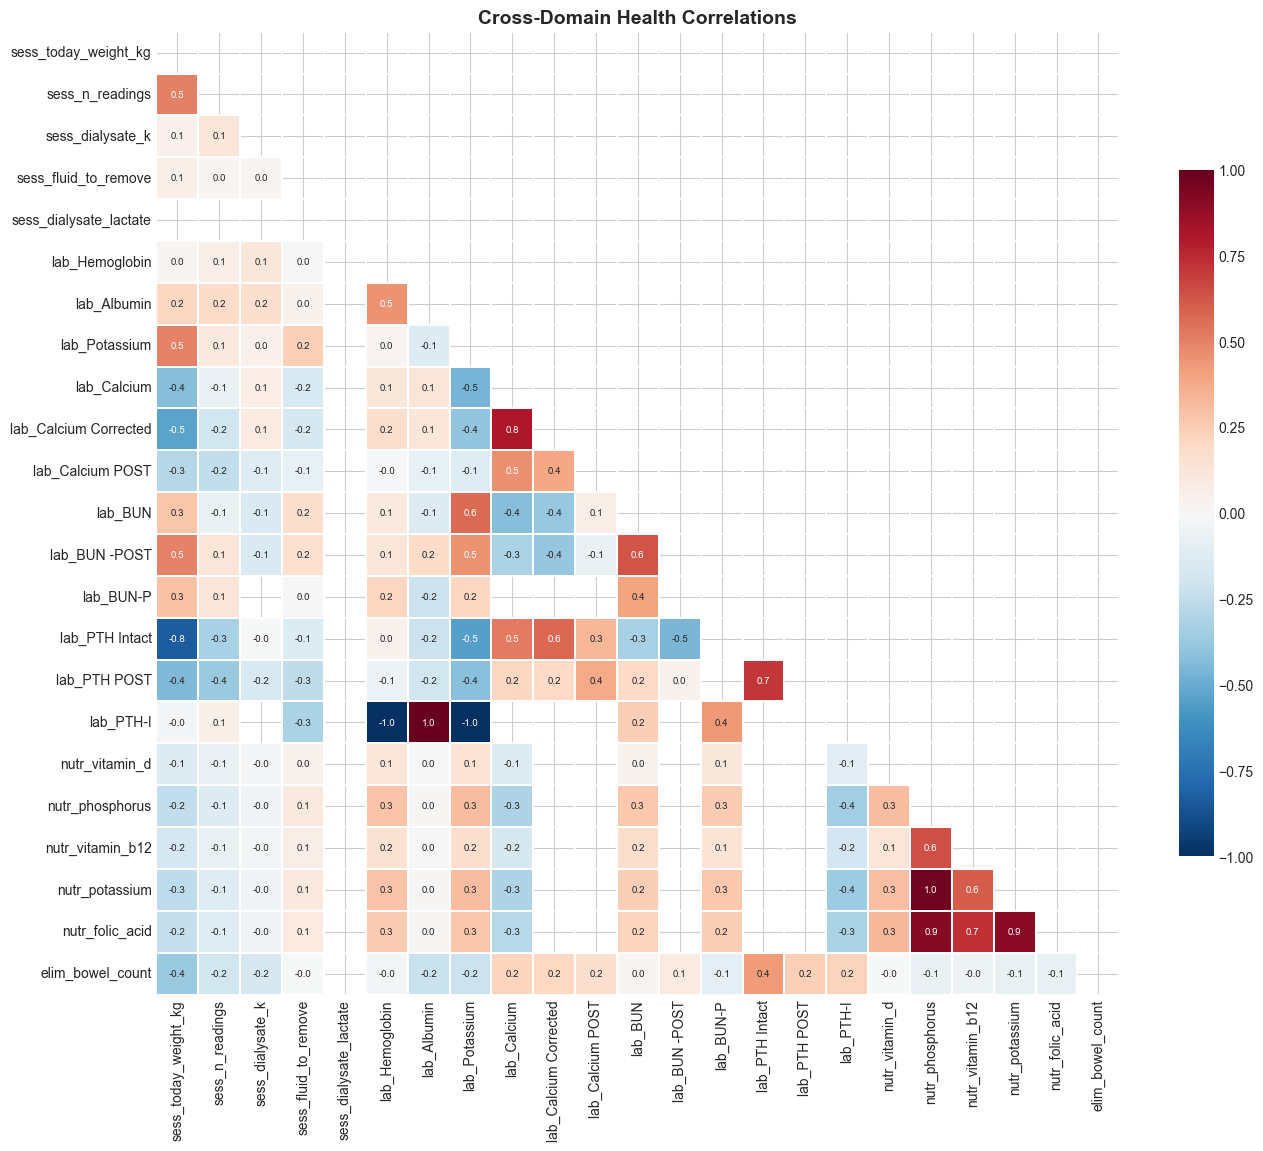

Top 15 strongest cross-domain correlations:
  -0.972  nutr_phosphorus  ↔  nutr_potassium
  -0.913  nutr_phosphorus  ↔  nutr_folic_acid
  -0.904  nutr_potassium  ↔  nutr_folic_acid
  -0.833  sess_today_weight_kg  ↔  lab_PTH Intact
  -0.811  lab_Calcium  ↔  lab_Calcium Corrected
  -0.734  nutr_vitamin_b12  ↔  nutr_folic_acid
  -0.715  lab_PTH Intact  ↔  lab_PTH POST
  -0.646  nutr_phosphorus  ↔  nutr_vitamin_b12
  -0.629  lab_BUN  ↔  lab_BUN -POST
  -0.603  nutr_vitamin_b12  ↔  nutr_potassium
  -0.576  lab_Calcium Corrected  ↔  lab_PTH Intact
  -0.567  lab_Potassium  ↔  lab_BUN
  -0.549  lab_Potassium  ↔  lab_PTH Intact
  -0.535  sess_today_weight_kg  ↔  lab_Calcium Corrected
  -0.517  lab_Calcium  ↔  lab_PTH Intact


In [13]:
# ── Correlation heatmap (features with sufficient data) ──
min_coverage = 0.05
good_cols = coverage[coverage >= min_coverage].index.tolist()

# Limit to manageable size
if len(good_cols) > 40:
    # Prioritize: session + key labs + nutrition
    priority_prefixes = ['sess_', 'lab_Hemoglobin', 'lab_Albumin', 'lab_Potassium',
                         'lab_Phosphorus', 'lab_Calcium', 'lab_BUN', 'lab_Creatinine',
                         'lab_PTH', 'nutr_', 'elim_']
    selected = []
    for prefix in priority_prefixes:
        selected.extend([c for c in good_cols if c.startswith(prefix)][:5])
    good_cols = list(dict.fromkeys(selected))[:40]  # deduplicate, limit

if len(good_cols) > 3:
    corr = daily[good_cols].corr()
    
    fig, ax = plt.subplots(figsize=(min(20, len(good_cols)*0.6), min(16, len(good_cols)*0.5)))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0,
                vmin=-1, vmax=1, annot=len(good_cols) <= 25, 
                fmt='.1f' if len(good_cols) <= 25 else '',
                square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax,
                annot_kws={'size': 7})
    ax.set_title('Cross-Domain Health Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Top correlations (excluding self)
    upper = corr.where(~mask)
    pairs = upper.unstack().dropna().abs()
    pairs = pairs[pairs < 0.99].sort_values(ascending=False)
    
    print("Top 15 strongest cross-domain correlations:")
    print("=" * 65)
    for (a, b), absval in pairs.head(15).items():
        sign = '+' if upper.loc[a, b] > 0 else '-'
        print(f"  {sign}{absval:.3f}  {a}  ↔  {b}")
else:
    print(f"Only {len(good_cols)} features with ≥{min_coverage:.0%} coverage — skipping correlation.")

---
## 9. Monthly Data Density Heatmap

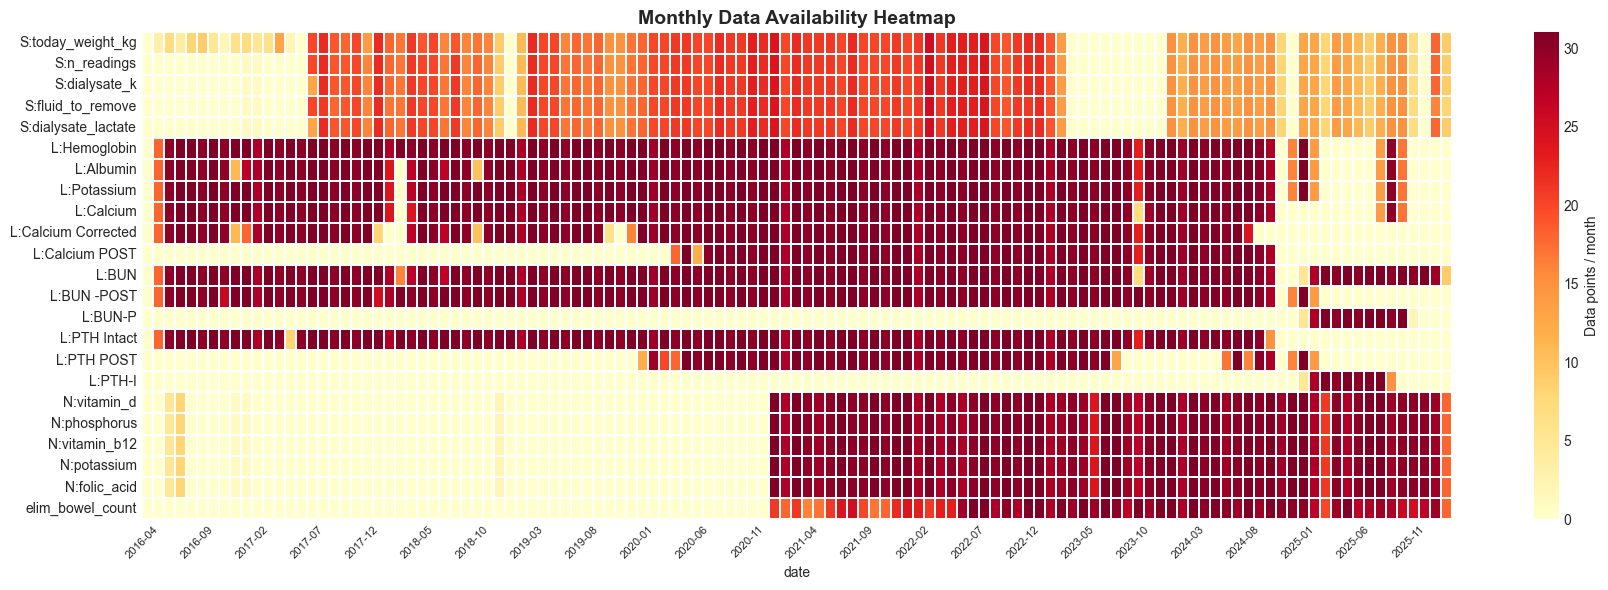

In [14]:
# Monthly availability heatmap
monthly_presence = daily[good_cols].resample('MS').apply(lambda x: x.notna().sum())

# Shorten labels
short = [c.replace('sess_', 'S:').replace('lab_', 'L:').replace('nutr_', 'N:') for c in good_cols]

fig, ax = plt.subplots(figsize=(18, max(6, len(good_cols)*0.25)))
data_plot = monthly_presence.T
data_plot.index = short
data_plot.columns = data_plot.columns.strftime('%Y-%m')

sns.heatmap(data_plot, cmap='YlOrRd', ax=ax, linewidths=0.3,
            cbar_kws={'label': 'Data points / month'})
ax.set_title('Monthly Data Availability Heatmap', fontsize=14, fontweight='bold')

# Show every Nth label
n_cols = len(data_plot.columns)
step = max(1, n_cols // 20)
ax.set_xticks(range(0, n_cols, step))
ax.set_xticklabels(data_plot.columns[::step], rotation=45, fontsize=8)
plt.tight_layout()
plt.show()

---
## 10. Key Statistics Summary

In [15]:
# ── Save daily unified matrix + summary ──
daily.to_csv(PROCESSED_DIR / 'daily_unified.csv')

print("=" * 70)
print("EXPLORATION SUMMARY")
print("=" * 70)
print(f"\n  Daily feature matrix:  {daily.shape[0]:,} days × {daily.shape[1]} features")
print(f"  Date span:             {daily.index.min().date()} → {daily.index.max().date()}")
span = (daily.index.max() - daily.index.min()).days
print(f"  Span:                  {span:,} days ({span/365:.1f} years)")
print(f"  Days with any data:    {daily.notna().any(axis=1).sum():,}")
print(f"\n  Saved: daily_unified.csv")
print(f"\n→ Next: Run 03_feature_engineering.ipynb")

EXPLORATION SUMMARY

  Daily feature matrix:  3,585 days × 388 features
  Date span:             2016-04-28 → 2026-02-19
  Span:                  3,584 days (9.8 years)
  Days with any data:    3,585

  Saved: daily_unified.csv

→ Next: Run 03_feature_engineering.ipynb
